# Programa para casa #6
Aluno: Igor Sales Bezerra Souza - Matrícula: 212405226

## Introdução

Este notebook apresenta a resolução do [Programa para Casa #6]('Programa_6.pdf') da disciplina de Métodos Numéricos. O foco desta atividade é a aplicação de métodos de otimização multidimensional sem restrições, abordando tanto abordagens diretas quanto baseadas em gradientes. São implementados e testados algoritmos clássicos como gradiente descendente (aclive máximo) e gradientes conjugados, assim como algoritmos de malha de busca uniforme e aleatória, com o objetivo de encontrar pontos críticos de funções. 

## Bibliotecas necessárias

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

A função a ser maximizada é: $F(x,y) = 4x+2y+x^2-2x^4+2xy-3y^2$. A seguir será possível entender as suas características com base em uma visualização 3D, em que se observa possuir ma região de máximo para o domínio ded [-3,3] nas direções x e y.

In [4]:
def obj_func(p):
    x, y = p
    return 4*x+2*y+x**2-2*x**4+2*x*y-3*y**2

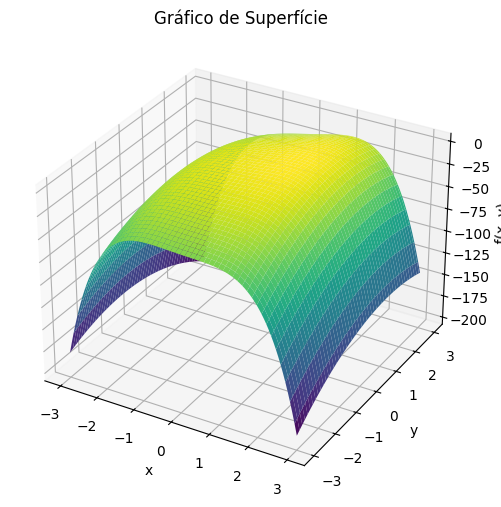

In [ ]:
# Criando os pontos do grid
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)
p = np.array([X, Y])
Z = obj_func(p)

# Criando a figura
plt.figure(figsize=(10,6))
ax = plt.axes(projection='3d')  # cria um subplot 3D diretamente
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
plt.title('Gráfico de Superfície')
plt.show()

## Busca aleatória e por malha unforme

In [14]:
Np = [50, 200, 350, 500, 700, 1000]

grid_args = [[0,0]]*len(Np)
grid_best_fit = [-np.inf]*len(Np)
grid_err_rel = [[100,100]]*len(Np)
t_grid = [0]*len(Np)

rand_args = [[0,0]]*len(Np)
rand_best_fit = [-np.inf]*len(Np)
rand_err_rel = [[100,100]]*len(Np)
t_rand = [0]*len(Np)

min_dom = -3
max_dom = 3

# Por mesh grid
for n in range(len(Np)):
    t0 = time.perf_counter()
    Xn_grid = np.linspace(min_dom, max_dom, Np[n])
    Yn_grid = np.linspace(min_dom, max_dom, Np[n])
    # X, Y = np.meshgrid(dim_1, dim_2)

    for x in range(len(Xn_grid)):
        for y in range(len(Yn_grid)):
            fit = obj_func(np.array([Xn_grid[x],Yn_grid[y]]))
            if fit > grid_best_fit[n]:
                grid_args[n] = np.array([x,y])
                grid_best_fit[n] = fit
    if n > 0:
        grid_err_rel[n] = (grid_args[n]-grid_args[n-1])/grid_args[n]*100
    t_grid[n] =  time.perf_counter() - t0 

# Por malha aleatória
for n in range(len(Np)):
    t0 = time.perf_counter()
    Xn_rand = np.random.uniform(min_dom, max_dom, Np[n])
    Yn_rand = np.random.uniform(min_dom, max_dom, Np[n])
    # X, Y = np.meshgrid(dim_1, dim_2)

    for x in range(len(Xn_rand)):
        for y in range(len(Yn_rand)):
            fit = obj_func(np.array([Xn_rand[x],Yn_rand[y]]))
            if fit > rand_best_fit[n]:
                rand_args[n] = np.array([x,y])
                rand_best_fit[n] = fit
    if n > 0:
        rand_err_rel[n] = (grid_args[n]-grid_args[n-1])/grid_args[n]*100
    t_rand[n] =  time.perf_counter() - t0


## Tabela de comparação das abordagens de malha uniforme e aleatória

In [27]:
grid_err_rel = [np.NaN]*len(Np)
rand_err_rel = [np.NaN]*len(Np)

for n in range(1,len(Np)):
    grid_err_rel[n] = abs((grid_best_fit[n]-grid_best_fit[n-1])/grid_best_fit[n])
    rand_err_rel[n] = abs((rand_best_fit[n]-rand_best_fit[n-1])/rand_best_fit[n])




print('Tabela dods resultados da malha de pontos uniforme:')
for i in range(len(Np)):
    if i == 0:
        print(f'Np = {Np[i]}   | Ponto Crítico: {grid_best_fit[i]:.4f} | Erro relativo: {grid_err_rel[i]:.4f}    | Custo Computacoinal: {t_grid[i]:.2f}s')
    elif i<len(Np)-1 and i>0:
        print(f'Np = {Np[i]}  | Ponto Crítico: {grid_best_fit[i]:.4f} | Erro relativo: {grid_err_rel[i]:.4f} | Custo Computacoinal: {t_grid[i]:.2f}s')
    else:
        print(f'Np = {Np[i]} | Ponto Crítico: {grid_best_fit[i]:.4f} | Erro relativo: {grid_err_rel[i]:.4f} | Custo Computacoinal: {t_grid[i]:.2f}s')

print('\r\n')

print('Tabela dods resultados da malha de pontos aleatórios:')
for i in range(len(Np)):
    if i == 0:
        print(f'Np = {Np[i]}   | Ponto Crítico: {rand_best_fit[i]:.4f} | Erro relativo: {rand_err_rel[i]:.4f}    | Custo Computacoinal: {t_rand[i]:.2f}s')
    elif i<len(Np)-1 and i>0:
        print(f'Np = {Np[i]}  | Ponto Crítico: {rand_best_fit[i]:.4f} | Erro relativo: {rand_err_rel[i]:.4f} | Custo Computacoinal: {t_rand[i]:.2f}s')
    else:
        print(f'Np = {Np[i]} | Ponto Crítico: {rand_best_fit[i]:.4f} | Erro relativo: {rand_err_rel[i]:.4f} | Custo Computacoinal: {t_rand[i]:.2f}s')

Tabela dods resultados da malha de pontos uniforme:
Np = 50   | Ponto Crítico: 4.3175 | Erro relativo: nan    | Custo Computacoinal: 0.02s
Np = 200  | Ponto Crítico: 4.3421 | Erro relativo: 0.0057 | Custo Computacoinal: 0.16s
Np = 350  | Ponto Crítico: 4.3438 | Erro relativo: 0.0004 | Custo Computacoinal: 0.52s
Np = 500  | Ponto Crítico: 4.3440 | Erro relativo: 0.0000 | Custo Computacoinal: 1.00s
Np = 700  | Ponto Crítico: 4.3440 | Erro relativo: 0.0000 | Custo Computacoinal: 1.87s
Np = 1000 | Ponto Crítico: 4.3439 | Erro relativo: 0.0000 | Custo Computacoinal: 3.46s


Tabela dods resultados da malha de pontos aleatórios:
Np = 50   | Ponto Crítico: 4.3414 | Erro relativo: nan    | Custo Computacoinal: 0.01s
Np = 200  | Ponto Crítico: 4.3420 | Erro relativo: 0.0001 | Custo Computacoinal: 0.15s
Np = 350  | Ponto Crítico: 4.3414 | Erro relativo: 0.0001 | Custo Computacoinal: 0.45s
Np = 500  | Ponto Crítico: 4.3435 | Erro relativo: 0.0005 | Custo Computacoinal: 0.83s
Np = 700  | Ponto Crít

### Observações
Foi possivel concluir que ambas as abordaegns chegaram no valor máximo de 4.3440, porém o método da malha uniforme alcançou esse valor com um menor número de pontos. Além disso, o custo computacional dos dois métodos foi bem parecido para um mesmo número de pontos na mala 

## Funções necessárias para rodar os metodos do aclive máximo e de gradientes congados

In [37]:
def gradiente(p):
    x, y = p
    return np.array([4 + 2*x - 8*x**3 +2*y, 2 + 2*x - 6*y])

def hessiana(p):
    x, _ = p
    H = np.array([[2-24*x, 2],[2, -6]])
    return H

def gl_h(p,df,h):
    x, y = p
    dfdx, dfdy = df
    return - 8*dfdx**4*h**3 - 24*x*dfdx**3*h**2 + (2*x**2-24*x**2*dfdx**2-6*dfdy**2+4*dfdx*dfdy)*h + (4*dfdx+2*dfdy+2*x*dfdx-8*x**3*dfdx+2*x*dfdy+2*y*dfdx-6*y*dfdy)

def ort_h(X,df,h):
    return gradiente(X + h*df).dot(df)

def sec_method(func, x_0, tol):
    """
    Método da secante para encontrar a raiz de uma função.

    Parâmetros:
    - func: função a ser analisada
    - x_0: primeira aproximação inicial da raiz
    - tol: tolerância para o erro relativo percentual

    Retorna:
    - xr: valor final da raiz aproximada
    - Err_rel: lista de erros relativos percentuais por iteração
    """

    x_prior = x_0     # x(n-1)
    eps = 10e-10

    Err_rel = [100]   # Erro inicial fictício para iniciar o loop
    i = 0             # Contador de iterações

    while abs(Err_rel[i]) > tol:
        if i >= 200: break
        x_actual = x_prior+eps

        # Cálculo da próxima aproximação com a fórmula da secante
        x_next = x_actual - (func(x_actual) * (x_prior - x_actual)) / (func(x_prior) - func(x_actual))

        # Cálculo do erro relativo percentual
        Err_rel.append((x_next - x_actual) / x_next * 100)

        # Atualização dos valores para a próxima iteração
        x_prior = x_actual
        x_actual = x_next

        i += 1  # Incremento do contador de iteração

    xr = x_next  # Aproximação final da raiz

    return xr, Err_rel

def golden_section(phi, a, b, tol = 1e-12, max_iter = 200):
    gr = (math.sqrt(5) - 1) / 2
    c  = b - gr * (b - a)
    d  = a + gr * (b - a)
    fc, fd = phi(c), phi(d)

    for _ in range(max_iter):
        if abs(b - a) < tol:
            break
        if fc < fd:
            a, c = c, d
            fc  = fd
            d   = a + gr * (b - a)
            fd  = phi(d)
        else:
            b, d = d, c
            fd  = fc
            c   = b - gr * (b - a)
            fc  = phi(c)
    return 0.5 * (a + b)

## Aclive máximo

In [47]:
def aclive_max(p, tol=0.01, iter_max=999):
    X = p
    x_track = [X[0]]
    y_track = [X[1]]
    Err_rel = 100

    for step in range(iter_max+1):
        if np.min(Err_rel)<tol: break

        df = gradiente(X)

        func = lambda h: gl_h(X,df,h)
        # func = lambda h: ort_h(X,df,h)

        h_0 = 0.01
        tol_sec = 1.0e-10
        h_r, _ = sec_method(func, h_0, tol_sec)

        if h_r <= 0 or h_r > 10:
            # print(f'Golden - step: {step}')
            phi = lambda hh : obj_func(X + hh*df)
            h_r = golden_section(phi,0, 10)

        Xn = X + h_r * df
        X_norm = np.linalg.norm(X)
        Xn_norm = np.linalg.norm(Xn)

        Err_rel = abs((Xn_norm-X_norm)/Xn_norm*100)
        xn, yn = Xn
        x_track.append(xn)
        y_track.append(yn)
        X = Xn

    return x_track, y_track, step, h_r

In [53]:
xt, yt, step, h_r= aclive_max(np.array([0,0]))

print(f' {step} passos foram realizados.')


 6 passos foram realizados.


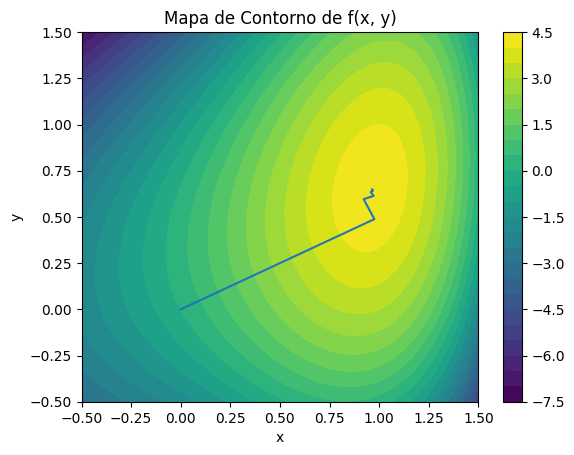

In [ ]:
# Criando os pontos do grid
x = np.linspace(-0.5, 1.5, 100)
y = np.linspace(-0.5, 1.5, 100)

X, Y = np.meshgrid(x, y)
p = np.array([X, Y])
Z = obj_func(p)

plt.contourf(X, Y, Z, levels=25, cmap='viridis')
plt.plot(xt,yt)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mapa de Contorno de f(x, y)')
plt.show()

In [41]:
H = hessiana(np.array([xt[-1],yt[-1]]))
print(f'Hessiana: \n {H}')

Hessiana: 
 [[-21.14752427   2.        ]
 [  2.          -6.        ]]


## Gradientes conjugados

In [44]:
def mult_conj_grad(p, tol=0.01, iter_max=999):
    X = p
    x_track = [X[0]]
    y_track = [X[1]]
    Err_rel = 100

    df = gradiente(X)
    d = df.copy()

    for step in range(iter_max+1):
        if np.min(Err_rel)<tol: break


        func = lambda h: gl_h(X,df,h)
        # func = lambda h: ort_h(X,df,h)

        h_0 = 0.01
        tol_sec = 1.0e-10
        h_r, _ = sec_method(func, h_0, tol_sec)

        if h_r <= 0 or h_r > 10:
            # print(f'Golden - step: {step}')
            phi = lambda hh : obj_func(X + hh*df)
            h_r = golden_section(phi,0, 10)

        Xn = X + h_r * d

        df_new = gradiente(Xn)

        beta = (df_new @ df_new)/(df @df)

        d = df_new + beta * d


        X_norm = np.linalg.norm(X)
        Xn_norm = np.linalg.norm(Xn)

        Err_rel = abs((Xn_norm-X_norm)/Xn_norm*100)
        xn, yn = Xn
        x_track.append(xn)
        y_track.append(yn)
        X = Xn
        df = df_new

    return x_track, y_track, step, h_r

In [52]:
xt_mcg, yt_mcg, step, h_r= mult_conj_grad(np.array([0,0]))

print(f' {step} passos foram realizados.')


 8 passos foram realizados.


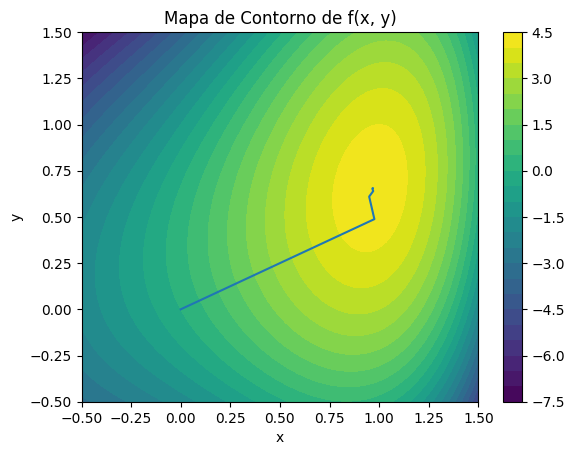

In [ ]:
# Criando os pontos do grid
x = np.linspace(-0.5, 1.5, 100)
y = np.linspace(-0.5, 1.5, 100)

X, Y = np.meshgrid(x, y)
p = np.array([X, Y])
Z = obj_func(p)

plt.contourf(X, Y, Z, levels=25, cmap='viridis')
plt.plot(xt_mcg,yt_mcg)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mapa de Contorno de f(x, y)')
plt.show()

In [42]:
H = hessiana(np.array([xt_mcg[-1],yt_mcg[-1]]))
print(f'Hessiana: \n {H}')

Hessiana: 
 [[-21.22187945   2.        ]
 [  2.          -6.        ]]


## Conclusões

Foi possível observar, como era esperado, que as direções de busca são aproximadamente ortogonais, pois uma aproximação numérica é realizadad para encontrar a raiz da derivada da função que corresponde ao número de passos na direção do gradiente, para o método do aclive máximo. E, que o método dos gradientes conjugados quebram um pouco contendo direções mais diistantes de 90°, devido a relação de direções mutuamente conjugadas. Além disso, o método do aclive máximo precisou de menos passos (6) em relação ao métodod dos gradientes conjugados (8) para o mesmo erro relativo. Por fim, analisando as hessiianas, os dois autovalores encontrados foram negativos, caracterizando um ponto de máximo. 